# Using Medigan for Synthetic Medical Image Segmentation

I've been working with **Medigan**, a framework offering a collection of pre-trained GAN models specifically designed for medical image generation. In our project, we started by exploring these models and selecting one capable of generating **synthetic polyp images and their corresponding masks**. These generated images form the training data for our next task — building a **segmentation model** using **DeepLabV3 with transfer learning**.

This approach helps address the common problem of limited annotated data in medical imaging. Synthetic data can be used for **data augmentation**, **pretraining**, or system evaluation, ultimately leading to more robust and effective AI models in healthcare.

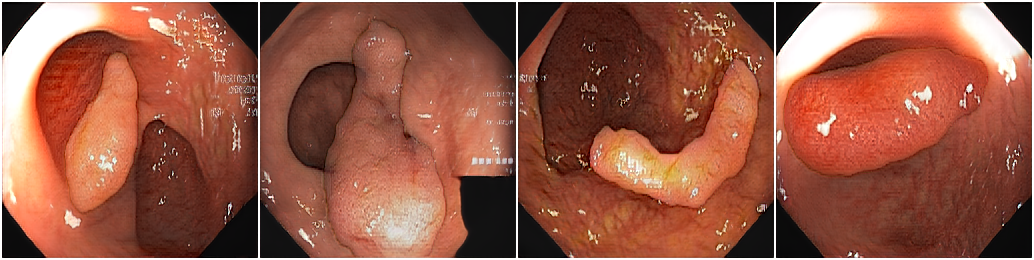

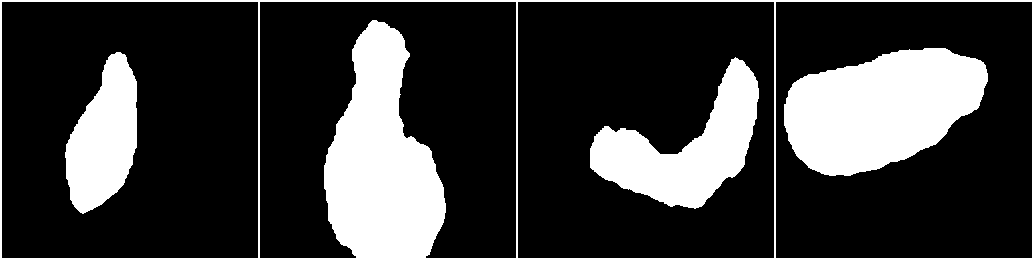

In [ ]:
from IPython.display import Image, display
display(Image(filename='/content/polyp.png'))
display(Image(filename='/content/poly_mask.png'))


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import medigan
import torch
import torch.optim as optim
import torchvision
from torchvision.io import read_image
from torchvision.utils import make_grid
from tqdm.notebook import tqdm

Since we'll be working with large models in this notebook, let's make sure we're using GPUs.

In [ ]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using {device} device.")

Using cuda device.


### Medigan Models

we are not creating our own GAN. But we can get pre-trained ones as well. One called [medigan](https://github.com/RichardObi/medigan) is exactly what we need — it generates medical images.

It's actually a whole collection of GANs. `medigan.Generators` gives us access to the GANs in the package. Here we can see the available ones, which you can also see [here](https://github.com/RichardObi/medigan?tab=readme-ov-file#available-models).

In [ ]:
generators = medigan.Generators()

list_of_models = generators.list_models()
print("Number of GANs models in medigan: ",len(list_of_models))

Number of GANs models in medigan:  23


In [ ]:
list_of_models[:4]

['00001_DCGAN_MMG_CALC_ROI',
 '00002_DCGAN_MMG_MASS_ROI',
 '00003_CYCLEGAN_MMG_DENSITY_FULL',
 '00004_PIX2PIX_MMG_MASSES_W_MASKS']

Each one has an id number (the first number in the name) and a somewhat descriptive name. But we'll want more information to decide which one we want. lets  get the configuration for the 19th , this tells us a lot about what the model does. The `model_id` can be either the id number or the whole name.

In [ ]:
model_00007_config = generators.get_config_by_id(model_id=19)
model_00007_config["selection"].keys()


dict_keys(['performance', 'use_cases', 'organ', 'modality', 'vendors', 'centres', 'function', 'condition', 'dataset', 'augmentations', 'generates', 'height', 'width', 'depth', 'type', 'license', 'dataset_type', 'privacy_preservation', 'tags', 'year'])

In [ ]:
model_00007_info = {key: model_00007_config["selection"][key] for key in ["organ", 'modality','tags']}
model_00007_info.update({key: model_00007_config["description"][key] for key in ["title", 'comment']})
model_00007_info

{'organ': ['lung', 'chest', 'thorax'],
 'modality': ['x-ray', 'xray', 'CXR'],
 'tags': ['Thoracic xray',
  'xray',
  'x-ray',
  'Thorax',
  'Lung',
  'Nodules',
  'Lung Cancer',
  'Lung Tumor'],
 'title': 'PGGAN Model for Generation of Chest XRAY (CXR) Images (Trained on the ChestX-ray14 Dataset)',
 'comment': 'An unconditional Progressively-growing generative adversarial network (PGGAN) that generates chest xray (CXR) images with pixel dimensions 1024x1024. The PGGAN was trained on CXR images from the ChestX-ray14 dataset (Wang et al., 2017, Paper: https://arxiv.org/pdf/1705.02315.pdf, Data: https://nihcc.app.box.com/v/ChestXray-NIHCC). The uploaded ZIP file contains the files model.pt (model weight), __init__.py (image generation method and utils), a requirements.txt, a LICENSE file, the MEDIGAN metadata.json file, the used GAN training config file, a test.sh file to run the model, and an /image folder with a few generated example images.'}

In [ ]:
model_00007_info["title"] = model_00007_config["description"]["title"]
model_00007_info["comment"] = model_00007_config["description"]["comment"]
model_00007_info

{'organ': ['lung', 'chest', 'thorax'],
 'modality': ['x-ray', 'xray', 'CXR'],
 'tags': ['Thoracic xray',
  'xray',
  'x-ray',
  'Thorax',
  'Lung',
  'Nodules',
  'Lung Cancer',
  'Lung Tumor'],
 'title': 'PGGAN Model for Generation of Chest XRAY (CXR) Images (Trained on the ChestX-ray14 Dataset)',
 'comment': 'An unconditional Progressively-growing generative adversarial network (PGGAN) that generates chest xray (CXR) images with pixel dimensions 1024x1024. The PGGAN was trained on CXR images from the ChestX-ray14 dataset (Wang et al., 2017, Paper: https://arxiv.org/pdf/1705.02315.pdf, Data: https://nihcc.app.box.com/v/ChestXray-NIHCC). The uploaded ZIP file contains the files model.pt (model weight), __init__.py (image generation method and utils), a requirements.txt, a LICENSE file, the MEDIGAN metadata.json file, the used GAN training config file, a test.sh file to run the model, and an /image folder with a few generated example images.'}

Let's find a model that gives lung X-rays. Let's look for high resolution images, so we have something nice to display on the screen when we use it to generate images.

Search for a model that is marked with lung, xray and 1024 (for
 by
 images, which will be easier for us as humans to understand).

In [ ]:
values_list = ['lung','xray',1024]

found_models = generators.find_matching_models_by_values(values=values_list, is_case_sensitive=False)

lung_xray_id = found_models[0].model_id

print(f"Lung x-ray model ID: {lung_xray_id}")

Lung x-ray model ID: 00019_PGGAN_CHEST_XRAY


### Generating Images

Now that we've picked a model, we can ask it to generate images for us. We do this with `generate`. We tell it which model and how many images (samples) to generate. It will go and download the model, set it up, then run it to create what we've asked for. By default, it creates the images as files and saves them to `output_path`, but we can also get them as a `numpy` array

We'll need to tell it where to save the outputs. It defaults to a directory with the model name and a timestamp, but we'll set it to something more memorable.

In [ ]:
output_dir = Path("output")
sample_dir = output_dir / "sample_lung"

print(sample_dir)

output/sample_lung


We'll generate $8$ lung x-ray images by setting `num_samples=8`. It should take a few seconds to create the images.

In [ ]:
import torch

_original_torch_load = torch.load

def patched_torch_load(*args, **kwargs):
    # Force weights_only=False if not explicitly set
    if 'weights_only' not in kwargs:
        kwargs['weights_only'] = False
    return _original_torch_load(*args, **kwargs)

torch.load = patched_torch_load


In [ ]:
import torch
from utils.config import BaseConfig

torch.serialization.add_safe_globals([BaseConfig])


In [ ]:
generators.generate(
    model_id=lung_xray_id,
    num_samples=8,
    output_path=sample_dir,
    install_dependencies = True,
)

100%|██████████| 1/1 [00:02<00:00,  2.84s/it]


And we can run this function to view a selection of the images in a directory.

In [ ]:
def view_images(directory, num_images=4, glob_rule="*"):
    """Displays a sample of images in the given directory
    They will display in rows of 4 images
    - directory: which directory to look for images
    - num_images: how many images to display (default 4, for one row)
    - glob_rule: argument to glob to filter images (default "*" selects all)"""

    image_list = list(directory.glob(glob_rule))
    num_samples = min(num_images, len(image_list))
    images = [read_image(str(f)) for f in sorted(image_list)[:num_samples]]
    grid = make_grid(images, nrow=4, pad_value=255.0)
    return torchvision.transforms.ToPILImage()(grid)

In [ ]:
view_images(sample_dir)

Output hidden; open in https://colab.research.google.com to view.

They look like chest x-rays, if a little strange. This is not unusual for a GAN, the images have basically the correct overall "shape" but the details aren't always right.

For the rest of the lesson, we'll be working with model `10`, named `00010_FASTGAN_POLYP_PATCHES_W_MASKS`. Let's see what it produces.

Generate $8$ images from model `10` and store them in the directory `output/polyp_samples`. Save the directory path in `polyp_dir`, we'll use it later. This may take a minute or so to run.

In [ ]:
model_id = 10
polyp_dir = output_dir / "polyp_samples"

generators.generate(model_id=model_id,
                    num_samples=8,
                    output_path=polyp_dir,
                    install_dependencies = True)

print(
    f"Created {len(list(polyp_dir.glob('*')))} images (should be twice the number asked for)"
)

100%|██████████| 1/1 [00:01<00:00,  1.65s/it]

Created 16 images (should be twice the number asked for)


This actually generates two kinds of images: the medical image, and a "mask". This is why we have twice the number we asked for, as we get one image and its mask for each sample we ask for. The images are endoscope images of polyps, or growths. Here are a few.

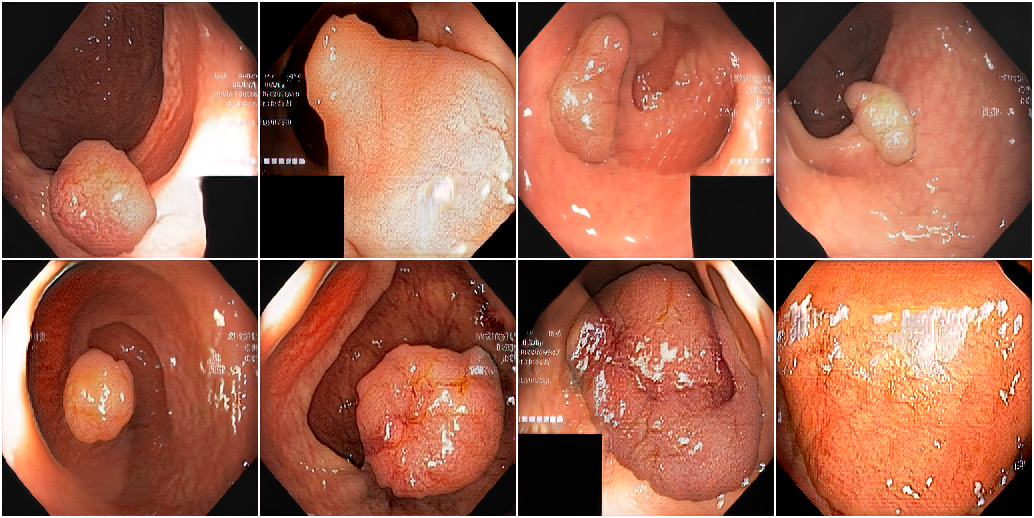

In [ ]:
view_images(polyp_dir, 8, "*img*")

The masks mark which parts of the image are polyps. These generally indicate some sort of problem, and we want to be able to detect them. Here are the masks for the images we generated.

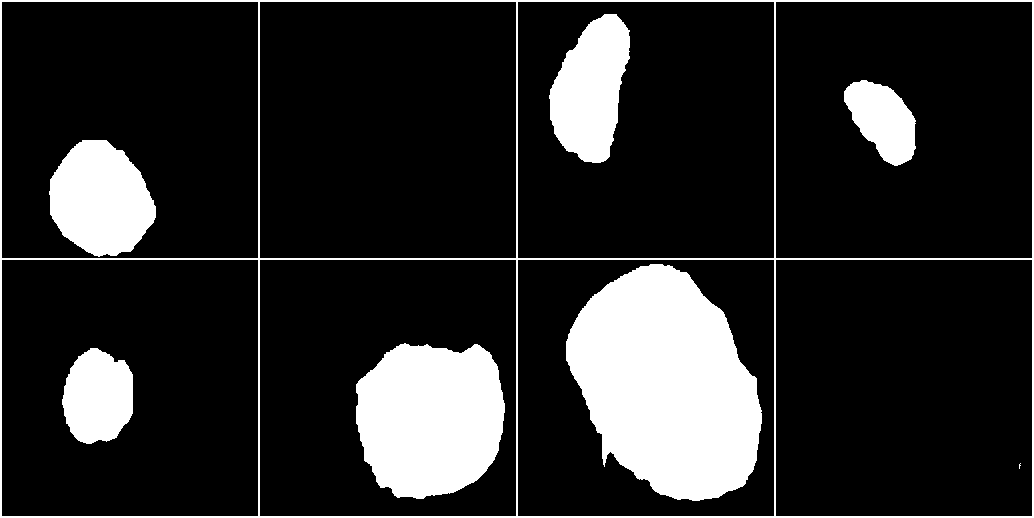

In [ ]:
view_images(polyp_dir, 8, "*mask*")

Depending on how your generation went, you could have mostly black images. These would be healthy images, where there was no problem. If so, you can re-run the generation to see what polyps and masks look like.

### Loading the Images

To enable us to do this, Medigan has provided us with `get_as_torch_dataloader`. This generates images and sets up a `DataLoader` for us, all in one step. We need to tell it which model to use (`model_id`), how many images to make in total (`num_samples`), how many in each batch (`batch_size`), and if we want to shuffle. As usual, we'll want to shuffle in training but not in validation. We'll also need to set `prefetch_factor=None` to avoid an error message.

This makes a training set with $200$ images, with $4$ images in a batch. We'll keep using model `10`.

In [ ]:
train_dataloader = generators.get_as_torch_dataloader(
    model_id=10, num_samples=200, batch_size=4, shuffle=True, prefetch_factor=None
)

We'll also need a validation data set.

data loader for validation data. This time we'll only have 30 images, and we won't shuffle. All other settings should be the same.

In [ ]:
val_dataloader = generators.get_as_torch_dataloader(
    model_id=10, num_samples=30, batch_size=4, shuffle=False, prefetch_factor=None
)

test_batch = next(iter(val_dataloader))
test_batch_sample = test_batch["sample"]
print(f"Getting batches of shape {test_batch_sample.shape}")

Getting batches of shape torch.Size([4, 256, 256, 3])


We saw before that this model generates both endoscope images and masks for them. Our data loader does the same, by giving us a dictionary with a `sample` key and a `mask` key. But this time each is a `torch` tensor rather than an image file.

Let's look at an example of each. If your mask is all black for a healthy image, you can run the previous cell again to get a fresh batch.

In [ ]:
test_batch.keys()

dict_keys(['sample', 'mask'])

Endoscope image shape: torch.Size([256, 256, 3])
Mask image shape: torch.Size([256, 256, 3])

Endoscope


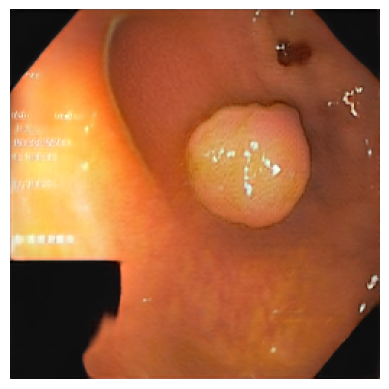

Mask


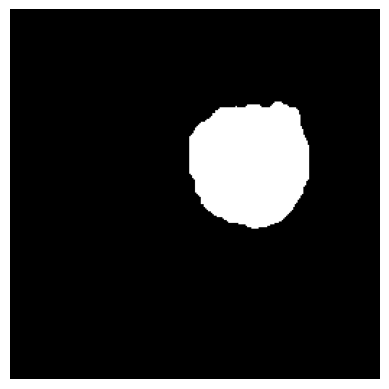

In [ ]:
endoscope = test_batch["sample"]
mask = test_batch["mask"]
print(f"Endoscope image shape: {endoscope[0].shape}")
print(f"Mask image shape: {mask[0].shape}")
print()

print("Endoscope")
plt.imshow(endoscope[0])
plt.axis("off")
plt.show()

print("Mask")
plt.imshow(mask[0])
plt.axis("off")
plt.show()

Looking deeper, the mask data is only `0` or `1`. This will make it a good label for a classifier. We can check that with `unique` — it will tell us all the different values in our tensor.

**Task 5.3.10:** Call the `unique` method of the `mask` tensor to verify it only has `0` and `1`.

In [ ]:
mask.unique()

tensor([0., 1.])

### Training a Model

We can use these data loaders to train a model. This model won't be a GAN, we already have one of those. Instead, we'll train a model that detects polyps on endoscope images. We'll use the images as the data, and the mask as the label. This should give us a model that takes in an image, and returns a mask highlighting any polyps. This would be quite useful to the medical industry, to speed up the processing of endoscope results and to double check in case the doctor may have missed something. Our GAN images aren't real data, but they're close enough to get a model doing the right low-level processing.

We could train a model from scratch, but as usual that isn't a good use of our time and resources. We'll do transfer learning, since there are many good pre-trained models that do this sort of detection of parts of an image. This process is called segmentation. A popular choice is `DeepLabV3`, so we'll use that. It's built into `torchvision`, we can load it in two lines.

In [ ]:
pretrained_weights = (
    torchvision.models.segmentation.DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
)
model = torchvision.models.segmentation.deeplabv3_resnet50(weights=pretrained_weights)

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth
100%|██████████| 161M/161M [00:01<00:00, 159MB/s]


This is a very large convolutional network, ending in a classifier. Let's look at the model overall. Note the rather large classifier at the end, you can ignore the `aux_classifier` as we won't be using it.

Let's see what shape it gives us. We have a `test_batch_sample` from a few cells ago, we can run that through the model. You may have noticed the shape is a typical image shape of `[4, 256, 256, 3]`, but torch likes tensors of shape `[4, 3, 256, 256]` (so the channels before the height and width). Also, the model has two outputs: `out` and `aux`. We'll only use `out`.

In [ ]:
test_batch_sample.shape

torch.Size([4, 256, 256, 3])

In [ ]:
sample_cuda = test_batch_sample.to(device)

model.to(device)
moved_channel = sample_cuda.permute(0, 3, 1, 2)
result = model(moved_channel)
out = result["out"]

output_shape = out.shape
print(f"Output shape: {output_shape}")

Output shape: torch.Size([4, 21, 256, 256])


This is _almost_ what we need. We need it to match our mask, which only has one channel. The mask tensor actually has three, but they're all the same, so we'll only use the first one.

In [ ]:
print(f"Shape from GAN: {test_batch['mask'].shape}")
print()
moved_channel_mask = test_batch["mask"][:, :, :, :1].permute(0, 3, 1, 2)
print(f"Shape we'll actually use: {moved_channel_mask.shape}")
print()

Shape from GAN: torch.Size([4, 256, 256, 3])

Shape we'll actually use: torch.Size([4, 1, 256, 256])



We'll need to do our usual process for transfer learning and modify the classifier part of the model. To minimize the training we'll need, we'll only replace the last layer. What is it currently?

In [ ]:
model.classifier[-1]

Conv2d(256, 21, kernel_size=(1, 1), stride=(1, 1))

This is a convolutional layer that takes $256$ channels in and gives $21$ channels out. A convolutional layer with a $1$ x $1$ kernel doesn't change the height or width of the image, but does change the number of channels. Since we're already getting the right height and width, we should only change the number of out channels.

We'll want to replace this with another convolutional layer with the same kernel, but only one channel output.

In [ ]:
new_final_layer = torch.nn.Conv2d(in_channels = 256, out_channels = 1, kernel_size = (1,1))

model.classifier[-1] = new_final_layer

model.to(device)
print(f"New output shape: {model(moved_channel)['out'].shape}")

New output shape: torch.Size([4, 1, 256, 256])


That's what we wanted. Now we need to train. Unfortunately, we can't use the training code from previous projects, as we need to separate the `sample` and `mask`, and change the order from `[batch, height, width, channel]` to `[batch, channel, height, weight]`. Also, we can't really compute the "accuracy", since our target isn't a single value, but rather a whole image. We'll only have the loss. Here is a training function that has those modifications.

In [ ]:
def train_model(
    model, train_dataloader, val_dataloader, criterion, optimizer, num_epochs
):
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        for data_dict in tqdm(train_dataloader):
            inputs = data_dict.get("sample")
            masks = data_dict.get("mask")
            # Reorder dimensions to [batch_size, channels, height, width]
            inputs = inputs.permute(0, 3, 1, 2)
            masks = masks.permute(0, 3, 1, 2)
            # Reduce mask to single channel
            masks = masks[:, :1, :, :]

            inputs = inputs.to(device)
            masks = masks.to(device)
            optimizer.zero_grad()

            # Select classifier output
            outputs = model(inputs)["out"]

            # Compute loss and step optimizer
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        epoch_loss = running_loss / len(train_dataloader.dataset)
        print(f"Epoch {epoch}/{num_epochs - 1}, Train Loss: {epoch_loss:.4f}")

        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for data_dict in tqdm(val_dataloader):
                inputs = data_dict.get("sample")
                masks = data_dict.get("mask")
                inputs = inputs.permute(0, 3, 1, 2)
                masks = masks.permute(0, 3, 1, 2)
                masks = masks[:, :1, :, :]

                inputs = inputs.to(device)
                masks = masks.to(device)

                outputs = model(inputs)["out"]
                loss = criterion(outputs, masks)
                val_loss += loss.item() * inputs.size(0)

        val_epoch_loss = val_loss / len(val_dataloader.dataset)
        print(f"Validation Loss: {val_epoch_loss:.4f}")

Our function takes a few arguments: `model`, `train_dataloader`, `val_dataloader`, `criterion`, `optimizer`, `num_epochs`. We have the first three already, now we need the `criterion` and the `optimizer`, and we'll need to decide how many epochs to train.

The `criterion` is our loss function. We'll use the Binary Cross Entropy again. But this time we're getting the raw logit output, rather than values between $0$ and $1$. The right one to use here is `BCEWithLogitsLoss`.

We need to create an optimizer as well. We'll use `Adam` again, as it's often a good choice. After some experimenting, we found this model is a bit prone to overfitting, so we'll slow the training down.

In [ ]:
# Define loss function and optimizer
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.0001)

print(
    f"Created optimizer of type {type(optimizer)} with learning rate {optimizer.defaults['lr']}"
)

Created optimizer of type <class 'torch.optim.adam.Adam'> with learning rate 0.0001


In [ ]:
train_model(
    model, train_dataloader, val_dataloader, criterion, optimizer, num_epochs=5
)

  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 0/4, Train Loss: 0.2044


  0%|          | 0/8 [00:00<?, ?it/s]

Validation Loss: 0.2003


  0%|          | 0/50 [00:00<?, ?it/s]

...

Validation Loss: 0.1869


  0%|          | 0/50 [00:00<?, ?it/s]

Epoch 4/4, Train Loss: 0.1059


  0%|          | 0/8 [00:00<?, ?it/s]

Validation Loss: 0.1318


# Prediction
Load the pre-trained model from `polyp_model.pth`

In [ ]:
# After training your model
torch.save(model.state_dict(), "polyp_model.pth")


In [ ]:
model_state = torch.load("polyp_model.pth")

# Load the state dictionary that has trained weights
model.load_state_dict(model_state)

<All keys matched successfully>

<div class="alert alert-info" role="alert">
You may have noticed that we didn't turn off training on the weights of the pre-trained model. This was intentional, as we found that if we did that the model performed quite poorly. In this situation, we needed to not just change the classification, but also tune the larger model. This is not uncommon. It often happens when what we want to do is a bit outside of what the model did originally, or when our data is sufficiently different from what the original model was trained on. In this case, it's more the latter. The model we're using was trained on a variety of full color images of people, animals, vehicles, etc. So we're specializing it a fair bit. And we found, again through experimenting, that it didn't take <i>too</i> much longer to train this way.
</div>

### Testing our Model

Great, we have a trained model! But we should make sure it's doing what we want.

Let's generate some new images to test it out.

## Testing
Create another data loader for model `10`. Only create $20$ images this time, in batches of $4$, without shuffling.

In [ ]:
test_dataloader = generators.get_as_torch_dataloader(model_id = 10, num_samples=20,batch_size=4, shuffle=False,prefetch_factor=None)

final_test_batch = next(iter(test_dataloader))
final_test_sample = final_test_batch["sample"]
final_test_mask = final_test_batch["mask"]

print(f"Test sample image shape: {final_test_sample.shape}")
print(f"Test mask image shape: {final_test_mask.shape}")

Test sample image shape: torch.Size([4, 256, 256, 3])
Test mask image shape: torch.Size([4, 256, 256, 3])


The previous cell pulled a batch from the loader. The data was separated into the images (`final_test_sample`) and the masks (`final_test_mask`). Now we need the output of the model to compare. We'll need to move the channels on the input, and select the `out` part of the output.

In [ ]:
# Permute the channel to the right place
final_moved_channels = final_test_sample.permute(0,3,1,2)

# Move to the device (GPU)
final_moved_channels_cuda = final_moved_channels.to(device)

# Run the model
final_model_result = model(final_moved_channels_cuda)

# Select the out part of the result
final_out = final_model_result["out"]

# Move the channel back to the last position so we can display the image
final_classifier_out = final_out.permute(0, 2, 3, 1)

print(f"Final images shape {final_classifier_out.shape}")

Final images shape torch.Size([4, 256, 256, 1])


If everything went according to plan, we should now have a `[4, 256, 256, 1]` tensor. That's four images. But we're not quite getting images, as we're getting the raw logits. We want a classifier type output, with values between $0$ and $1$. We're getting something else.

In [ ]:
print("Getting range:")
final_classifier_out.min().item(), final_classifier_out.max().item()

Getting range:


(-3.90008807182312, 9.719432830810547)

We can repair that by running the result through a sigmoid function, which will ensure every value is between $0$ and $1$.

In [ ]:
final_classifier_image = torch.sigmoid(final_classifier_out)

We're ready for the final reveal!

Here's a function that will plot the images in a torch tensor, in rows of $4$.

In [ ]:
def plot_images_from_tensor(tensor):
    grid = make_grid(tensor.permute(0, 3, 1, 2), nrow=4, pad_value=1.0)
    return torchvision.transforms.ToPILImage()(grid)

We can run this on our `final_test_sample` to see the input endoscope images.

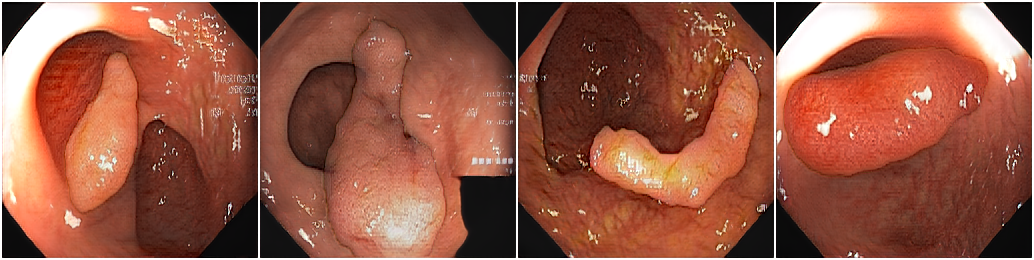

In [ ]:
plot_images_from_tensor(final_test_sample)

This same function will work on our masks. We can compare the mask that we expect to be correct (`final_test_mask`) with our output (`final_classifier_image`) to see how our model performed.

 `plot_images_from_tensor` on the `final_test_mask` and `final_classifier_image`. You'll need to do it in different cells.

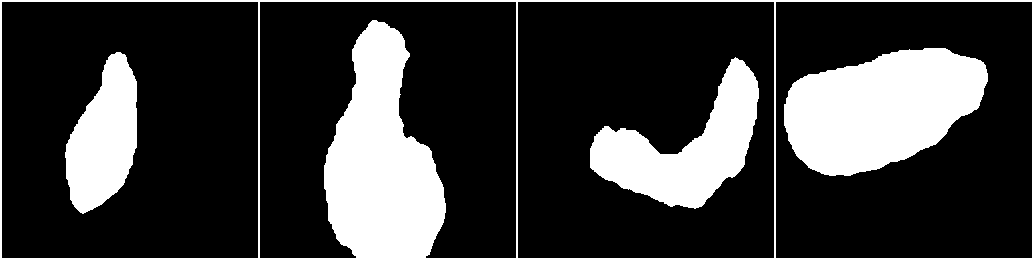

In [ ]:
# Plot the final_test_mask — the "right answer"
plot_images_from_tensor(final_test_mask)

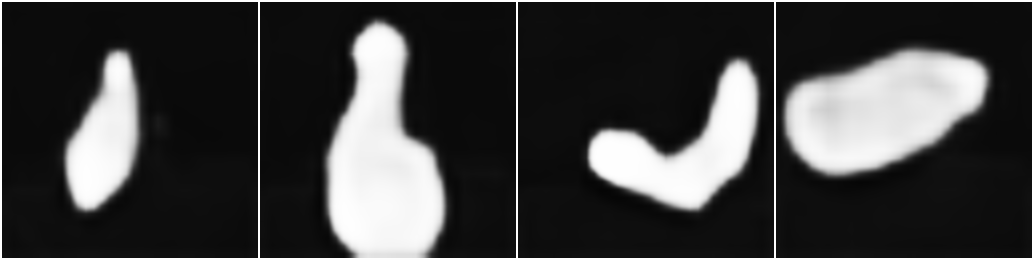

In [ ]:
# Plot the final_classifier_image - what our model outputs
plot_images_from_tensor(final_classifier_image)

That did quite well, especially considering that it only took a few minutes to train!

This wouldn't be the final model we'd apply to actual medical images. We'd need to fine tune it further on real data, that had been marked by an expert. But the model is in _extremely_ good shape and ready for that last bit of training, which should only take a few epochs to get the tuning right.